## 1. Assign & Plot Temperature Values (Boston Example)

This notebook shows how the collected data was processed to assign temperature values to tree crowns and the surrounding context

In [1]:
import os, shutil, cv2,datetime, torch, torchvision.transforms, json, torchvision, copy, time, open_clip, sys,PIL.Image
os.chdir('/home/klimenko/CoolingMachines/explore_flir')
import matplotlib.pyplot as plt
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
from PIL import Image
import time
import numpy as np
from scipy.ndimage import zoom
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image,ImageFile
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from torch.utils.data import random_split
import torch.nn as nn
import pandas as pd
from collections import Counter


####################################
# ADE20K-based Scene Parsing Segmentation to Extract Facade
###################################

# This module (mit_semseg) is identical to https://pypi.org/project/mit-semseg/
# Obtainted from:  https://github.com/CSAILVision/sceneparsing

# Reference: Semantic Understanding of Scenes through ADE20K Dataset. 
# B. Zhou, H. Zhao, X. Puig, T. Xiao, S. Fidler, A. Barriuso and A. Torralba.
# International Journal on Computer Vision (IJCV), 2018. (https://arxiv.org/pdf/1608.05442.pdf)

from mit_semseg.config import cfg
from mit_semseg.dataset import TestDataset
from mit_semseg.models import ModelBuilder, SegmentationModule


net_encoder = ModelBuilder.build_encoder(arch='resnet50dilated',fc_dim=2048,weights='ckpt/ade20k-resnet50dilated-ppm_deepsup/encoder_epoch_20.pth')
net_decoder = ModelBuilder.build_decoder(arch='ppm_deepsup',fc_dim=2048,num_class=150,weights='ckpt/ade20k-resnet50dilated-ppm_deepsup/decoder_epoch_20.pth',use_softmax=True)
crit = torch.nn.NLLLoss(ignore_index=-1)
segmentation_module = SegmentationModule(net_encoder, net_decoder, crit)
segmentation_module.eval()
device = torch.device("cuda:0")
segmentation_module.to(device)
pil_to_tensor = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  ])


Couldn't import dot_parser, loading of dot files will not be possible.


/home/klimenko/anaconda3/envs/facade/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


/home/klimenko/CoolingMachines/explore_flir
Loading weights for net_encoder
Loading weights for net_decoder


In [2]:
# Package the segmentation function to only output the segmentation mask as required

def segment_image(path):
    pil_image = PIL.Image.open(path).convert('RGB')
    width, height = pil_image.size
    resized_pil_image = pil_image
    img_data = pil_to_tensor(resized_pil_image)
    singleton_batch = {'img_data': img_data[None].to(device)}
    output_size = img_data.shape[1:]
    with torch.no_grad():
        scores = segmentation_module(singleton_batch, segSize=output_size)
    _, pred = torch.max(scores, dim=1)
    pred = pred.cpu()[0].numpy()
    return pred

In [3]:
# Example plotting segmentation over one image

morning = pd.read_csv('/home/klimenko/CoolingMachines/explore_flir/dataset/BOSTON_FLIR_DATASET/all.csv')

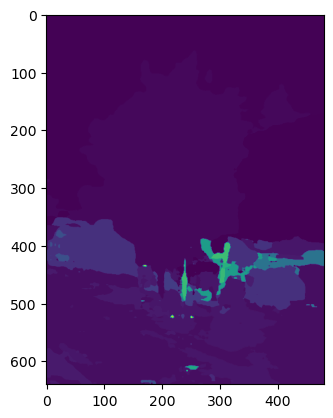

In [45]:
ii = 130
a = segment_image(morning['visual_path'][ii])
a = cv2.resize(a.astype(np.float32), (480, 640))
plt.imshow(a, cmap='viridis')

In [46]:
visual = cv2.imread(morning['visual_path'][ii])
visual = cv2.resize(visual, (480, 640))
visual = cv2.cvtColor(visual, cv2.COLOR_BGR2RGB)

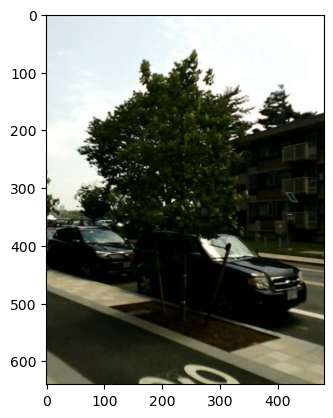

In [47]:
plt.imshow(visual)

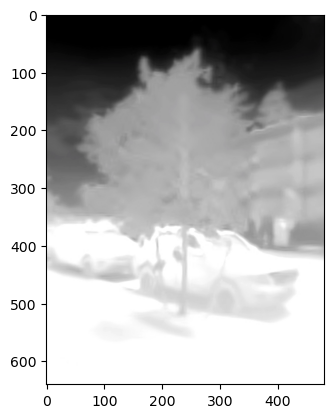

In [48]:
thermal = cv2.imread(morning['thermal_path'][ii])
plt.imshow(thermal)

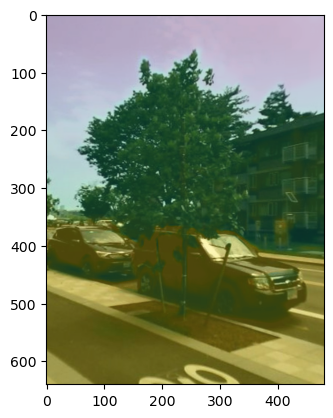

In [49]:
plt.imshow(thermal[:,:,0])
plt.imshow(visual, alpha=0.7)

In [ ]:
# We separately export temperature gradient bars 
# and raw thermal images and rescale to obtain temperature values

def obtain_temp_scale(img_fresh, scalebar):
    linear_interpolation_array_temp = np.linspace(0,40, len(scalebar)).astype(float)
    img_temp = np.interp(img_fresh[:,:,0].astype(np.float32),scalebar[:,0], linear_interpolation_array_temp)
    return img_temp

In [ ]:
# Run for all image pairs, compute mean temperature in trees and other surfaces

def extract_temperature(visual_path, thermal_path):
    pred = segment_image(visual_path)
    
    thermal_img_fresh = cv2.imread(thermal_path)
    thermal_img_fresh = cv2.resize(thermal_img_fresh.astype(np.float32), (480, 640))
    
    file_name, file_extension = os.path.splitext(os.path.basename(thermal_path))
    
    new_file_name = file_name + file_extension.lower().replace(".jpeg", ".jpg") + ".npy"
    scalebar = np.load('dataset/BOSTON_FLIR_DATASET/all/watermarked/'+new_file_name)
    thermal = obtain_temp_scale(thermal_img_fresh, scalebar)
    
    
    b = cv2.imread(visual_path)
    green_mask = np.where(b[:,:,0]<60, 1, 0)
    

    tree_mask = np.where(pred==4, 1, 0) # 4 = tree label in the segmentation
    total_mask = tree_mask*green_mask
    canopy_density = np.sum(total_mask)/np.sum(tree_mask)
    tree_mask = total_mask
    
    tree_mask = cv2.resize(tree_mask.astype(np.float32), (480, 640))
    tree_mask = tree_mask * thermal[:,:]
    tree_mask[tree_mask < 10] = np.nan
    tree_temperature = np.nanmean(tree_mask[tree_mask > 0])
    

    other_mask = np.isin(pred, [4, 5, 20, 2]).astype(np.float32)  # 5, 20, 2 refer to building, wall, and road surfaces
    other_mask = 1 - other_mask
    other_mask = cv2.resize(other_mask.astype(np.float32), (480, 640))
    
    
    other_mask = other_mask * thermal[:,:]

    other_mask[other_mask < 10] = np.nan
    other_temperature = np.nanmean(other_mask[other_mask > 0])

    
    
    
    
    
    return tree_temperature, other_temperature, canopy_density
    
    

In [ ]:
tree_temperature, other_temperature, canopy_density = extract_temperature(df['visual_path'][33], df['thermal_path'][33])

In [31]:
df = pd.read_csv('dataset/BOSTON_FLIR_DATASET/all.csv')

In [36]:
import pandas as pd
import cv2

df = pd.read_csv('dataset/BOSTON_FLIR_DATASET/all.csv')
tree_temperature_values = []
other_temperature_values = []
canopy_density_values = []

# Loop over the rows in the DataFrame and apply the function
total_rows = len(df)
for idx, row in df.iterrows():
    
    try:
        # Extract values using the image path and info
        tree_temperature, other_temperature, canopy_density = extract_temperature(row['visual_path'], row['thermal_path'])

        # Append the results to the respective lists
        tree_temperature_values.append(tree_temperature)
        other_temperature_values.append(other_temperature)
        canopy_density_values.append(canopy_density)

        # Print progress manually
        if (idx + 1) % 10 == 0 or (idx + 1) == total_rows:
            print(f"Processed {idx + 1}/{total_rows} rows")
            
    except:
        print('F')
        tree_temperature_values.append(np.nan)
        other_temperature_values.append(np.nan)
        canopy_density_values.append(np.nan)

# Add the computed values as new columns in the DataFrame
df['tree_temperature_scaled_threshold'] = tree_temperature_values
df['other_temperature_scaled_threshold'] = other_temperature_values
df['canopy_density'] = canopy_density_values

Processed 10/497 rows
Processed 20/497 rows
Processed 30/497 rows
Processed 40/497 rows
Processed 50/497 rows
Processed 60/497 rows
Processed 70/497 rows
Processed 80/497 rows
Processed 90/497 rows
Processed 100/497 rows
Processed 110/497 rows
Processed 120/497 rows
Processed 130/497 rows
Processed 140/497 rows
Processed 150/497 rows
Processed 160/497 rows
Processed 170/497 rows
Processed 180/497 rows
Processed 190/497 rows
Processed 200/497 rows
Processed 210/497 rows
Processed 220/497 rows
Processed 230/497 rows
Processed 240/497 rows
Processed 250/497 rows
Processed 260/497 rows
Processed 270/497 rows
Processed 280/497 rows
Processed 290/497 rows
Processed 300/497 rows
Processed 310/497 rows
Processed 320/497 rows
Processed 330/497 rows
Processed 340/497 rows
Processed 350/497 rows
Processed 360/497 rows
Processed 370/497 rows
Processed 380/497 rows
Processed 390/497 rows
Processed 400/497 rows
Processed 410/497 rows
Processed 420/497 rows
Processed 430/497 rows
Processed 440/497 ro

In [1]:
import pandas as pd

df = pd.read_csv('/home/klimenko/CoolingMachines/explore_flir/dataset/BOSTON_FLIR_DATASET/all.csv')

In [9]:
# convert to hours since start of day
df['POINT_NAME'] = pd.to_datetime(df['POINT_NAME'], format='%d%b%y %H:%M')
df['hours_since_start_of_day'] = (df['POINT_NAME'].dt.hour + df['POINT_NAME'].dt.minute / 60.0)
df.to_csv('/home/klimenko/CoolingMachines/explore_flir/dataset/BOSTON_FLIR_DATASET/all.csv')

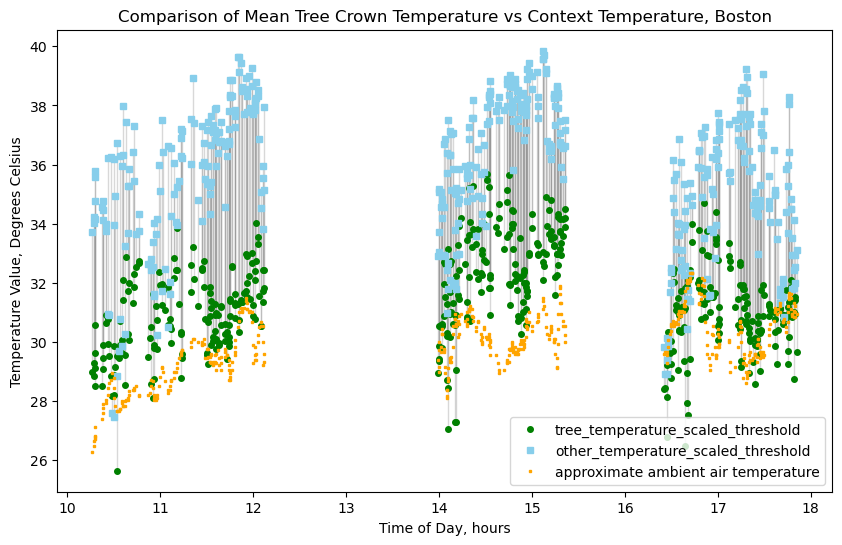

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = df

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(df)):
    ax.plot([df['hours_since_start_of_day'][i], df['hours_since_start_of_day'][i]], [df['other_temperature_scaled_threshold'][i], df['tree_temperature_scaled_threshold'][i]], color='gray', linestyle='-', marker='None', alpha = 0.3, linewidth = 1)  # Vertical line between A and B


# Plotting values from column A with one color
ax.plot(df['hours_since_start_of_day'], df['tree_temperature_scaled_threshold'], label='tree_temperature_scaled_threshold', color='green', marker='o', linestyle ='None',markersize=4)

# Plotting values from column B with another color
ax.plot(df['hours_since_start_of_day'], df['other_temperature_scaled_threshold'], label='other_temperature_scaled_threshold', color='skyblue', marker='s', linestyle ='None',markersize=4)

# Plotting values from column B with another color
ax.plot(df['hours_since_start_of_day'], df['temperature_kestrel'], label='approximate ambient air temperature', color='orange', marker='s', linestyle ='None', markersize=2)



# Add labels and title
ax.set_xlabel('Time of Day, hours')
ax.set_ylabel('Temperature Value, Degrees Celsius')
ax.set_title('Comparison of Mean Tree Crown Temperature vs Context Temperature, Boston')

# Display a legend to differentiate the lines
ax.legend()

# Show the plot
plt.show()